[Material used to generate Fig.6, Fig.10]

Visualization of the infiltrability properties of seepage profiles from previous studies and synthetic distributions.

In [2]:
# Standard imports
import sys
import pathlib
import json

# Third party imports
import numpy as np
import pandas as pd
import colorstamps
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
from matplotlib.lines import Line2D

# Internal imports
sys.path.append('..')
import rose 
import dless
from map import plot_streambed

In [3]:
# set plot style
%matplotlib widget
plt.style.use('plot_style.txt')

# output path for figures 
output_path = pathlib.Path("/home/jonas/shared/Work/SSeep2026/Figures")

# set regime colors
c_negl = '#5a7cb0b3'
c_soft = '#e16e91b3'
c_hard = '#c9aa2ab3'

# Kelly's pallette
colorPalette = ["#fdfdfd", "#1d1d1d", "#ebce2b", "#702c8c", "#db6917",
                "#96cde6", "#ba1c30", "#c0bd7f", "#7f7e80", "#5fa641",
                "#d485b2", "#4277b6", "#463397", "#e1a11a", "#91218c",
                "#e8e948", "#7e1510", "#92ae31", "#d32b1e", "#2b3514",
                "#36515e"]

### What texture best corresponds to geologic units
Compare van Genuchten unsaturated parameters used for near‐surface geological units in numerical simulations (compiled by Muñoz-Vega et al., https://doi.org/10.1029/2025WR040785) with sand and sandy loam distributions obtained from Rosetta3.

load data

In [4]:
munoz_data = pd.read_csv('../data/munoz_unsat_ref.csv')

generate synthetic distributions of sand and sandy loam

In [5]:
N = 2000 # sample size
sand = rose.sample_from_class('SAND', N)
sand_loam = rose.sample_from_class('SAND_LOAM', N)

plot distributions of hydraulic conductivity, scale parameter and shape parameter

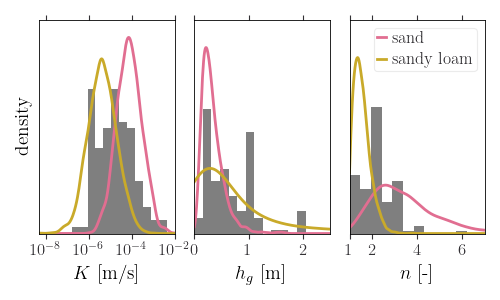

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(5, 3))
for ax in axs: 
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(top=True, left=False, right=False)
    ax.minorticks_off()


# histogram properties
n = 300
n_bins = 20



# first panel (hydraulic conductivity)
log_Kmin = -9
log_Kmax = -2

x = np.linspace(log_Kmin, log_Kmax, n)
delta = (log_Kmax - log_Kmin) / n

X = np.log10(sand['K'])
kde = stats.gaussian_kde(X)
y = kde(x) * X.shape[0]
y /= (y.sum() * delta)
axs[0].plot(10**x, y, lw=2, color='C1', label='sand')

X = np.log10(sand_loam['K'])
kde = stats.gaussian_kde(X)
y = kde(x) * X.shape[0]
y /= (y.sum() * delta)
axs[0].plot(10**x, y, lw=2, color='C2', label='sandy loam')

logbins = np.logspace(log_Kmin, log_Kmax, n_bins)
delta_bins = (log_Kmax - log_Kmin) / n_bins
hist, bins = np.histogram(munoz_data['K'], bins=logbins)
hist = hist / (len(munoz_data['K']) * delta_bins)
axs[0].stairs(hist, bins, fill=True, color='k', alpha=0.5)

axs[0].set(xscale='log', yscale='linear')
axs[0].set_xlim(xmin=5e-9, xmax=1e-2)
axs[0].set_ylim(ymax=0.75)
axs[0].set_xticks([1e-8, 1e-6, 1e-4, 1e-2])
axs[0].set_yticks([])
axs[0].set_xlabel('$K$ [m/s]', labelpad=5)
axs[0].set_ylabel('density', labelpad=5)



# second panel (scale parameter)
hgmin = 0
hgmax = 3

x = np.linspace(hgmin, hgmax, n)
delta = (hgmax - hgmin) / n

X = sand['hg']
kde = stats.gaussian_kde(X)
y = kde(x) * X.shape[0]
y /= (y.sum() * delta)
axs[1].plot(x, y, lw=2, color='C1', label='sand')

X = sand_loam['hg']
kde = stats.gaussian_kde(X)
y = kde(x) * X.shape[0]
y /= (y.sum() * delta)
axs[1].plot(x, y, lw=2, color='C2', label='sandy loam')

n_bins = 20
logbins = np.linspace(hgmin, hgmax, n_bins)
delta_bins = (hgmax - hgmin) / n_bins
hist, bins = np.histogram(munoz_data['hg'], bins=logbins)
hist = hist / (len(munoz_data['hg']) * delta_bins)
axs[1].stairs(hist, bins, fill=True, color='k', alpha=0.5)

axs[1].set(xscale='linear', yscale='linear')
axs[1].set_xlim(xmin=0, xmax=2.5)
axs[1].set_ylim(ymax=3.05)
axs[1].set_xlabel('$h_g$ [m]', labelpad=5)
axs[1].set_xticks([0, 1, 2])
axs[1].set_yticks([])



# third panel (shape parameter)
nmin = 1
nmax = 10

x = np.linspace(nmin, nmax, n)
delta = (nmax - nmin) / n

X = sand['n']
kde = stats.gaussian_kde(X)
y = kde(x) * X.shape[0]
y /= (y.sum() * delta)
axs[2].plot(x, y, lw=2, color='C1', label='sand')

X = sand_loam['n']
kde = stats.gaussian_kde(X)
y = kde(x) * X.shape[0]
y /= (y.sum() * delta)
axs[2].plot(x, y, lw=2, color='C2', label='sandy loam')

logbins = np.linspace(nmin, nmax, n_bins)
delta_bins = (nmax - nmin) / n_bins
hist, bins = np.histogram(munoz_data['n'], bins=logbins)
hist = hist / (len(munoz_data['n']) * delta_bins)
axs[2].stairs(hist, bins, fill=True, color='k', alpha=0.5)

axs[2].set(xscale='linear', yscale='linear')
axs[2].set_xlim(xmin=1, xmax=7)
axs[2].set_ylim(ymax=1.45)
axs[2].set_xlabel('$n$ [-]', labelpad=5)
axs[2].set_xticks([1, 2, 4, 6])
axs[2].set_yticks([])
axs[2].legend(loc='upper right', handlelength=.5, handletextpad=0.4, fontsize=12)


plt.tight_layout(w_pad=0)
#plt.savefig(output_path / 'unsat_distribution.pdf')

### Compilation of streambed profiles

Plot in the infiltability plane the coordinates of streambed profiles reported in the literature. Synthetic conﬁgurations are indicated by a * in the legend. Field measurements of streams (width < 10 m) and rivers (width > 10 m) are respectively indicated with a s and a r in the legend.

Load collected data from the file ./data/streambeds.json

In [7]:
with open('../data/streambeds.json') as f:
    sb = json.load(f)

Bruen2004
Brunner2009a
Brunner2009b
Fox2003
Irvine2012
Newcomer2016
Osman2002
Riviere2014
Shanafield2012
Xian2017
Wang2011
BattleAguilar2012
Kalbus2009
Battin1998
Brookfield2009
Crosbie2014
Fleckenstein2006


/home/jonas/shared/Work/SSeep2026/stream-seepage/experiments/map.py:278: RuntimeWarning: invalid value encountered in scalar power
  if (ne_new**2-ne_old**2)**.5 + (d50_new**2-d50_old**2)**.5 < 1e-4:


Lamontagne2012
Reid1990
Su2007
Younger1993
Younger1993


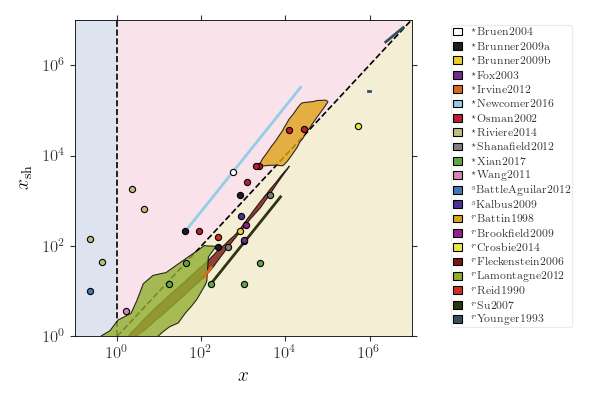

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.tick_params(top=True, right=True)
ax.set(xscale='linear', yscale='linear')
ax.minorticks_off()
ax.set_xlim(xmin=-1, xmax=7)
ax.set_ylim(ymin=0, ymax=7)
ax.set_yticks([0, 2, 4, 6], labels=[])
ax.set_xticks([0, 2, 4, 6])


# background with the regimes
ax.fill_betweenx([0, 7], [-2, -2], x2=[0, 0], color=c_negl,
                    ec='None', zorder=0, alpha=0.2)
ax.fill_between([0, 10], [0, 10], y2=[10, 10], color=c_soft,
                ec='None', zorder=0, alpha=0.2)
ax.fill_between([0, 10], [0, 0], y2=[0, 10], color=c_hard,
                ec='None', zorder=0, alpha=0.2)
ax.plot([0, 0], [0, 10], ls='--', c='k', zorder=0)
ax.plot([0, 10], [0, 10], ls='--', c='k', zorder=0)


# plot the data
labels = []
for x in sb:
    color = colorPalette[x['id'] - 1]
    plot_streambed(x, ax, labels, color)


# layout
ax.set_xlabel('$x$', labelpad=5)
ax.set_xticklabels(['$10^0$', '$10^2$', '$10^4$', '$10^6$'])
ax.set_ylabel('$x_\\mathrm{sh}$', labelpad=8)
ax.set_yticklabels(['$10^0$', '$10^2$', '$10^4$', '$10^6$'])

ax.legend(handles=labels, loc='upper left', bbox_to_anchor=(1.1, 1.),
          fontsize=8, handlelength=0.8, ncols=1, columnspacing=0.8)
plt.tight_layout()
#plt.savefig(output_path / "sb_compilation.pdf")

### Representative streambed profiles on the infiltrability map

Generate streambed profiles:

    - with sand or sandy loam, 
    - with wc from Unif(0, 2) [m]
    - with Kc from LogUnif(1e-8, 1e-6) [m/s]

and plot them on the infiltrability map.

generate riverbed profiles

In [9]:
N = 1000 # sample size
sand = rose.sample_from_class('SAND', N)
sand_loam = rose.sample_from_class('SAND_LOAM', N)

cl_cond = 10**np.random.uniform(low=-8, high=-6, size=N)
cl_th = np.random.uniform(low=0, high=2, size=N)

[SAND] unclogged fraction: 0.00
[SAND LOAM] unclogged fraction: 0.03


/tmp/ipykernel_13293/606889621.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


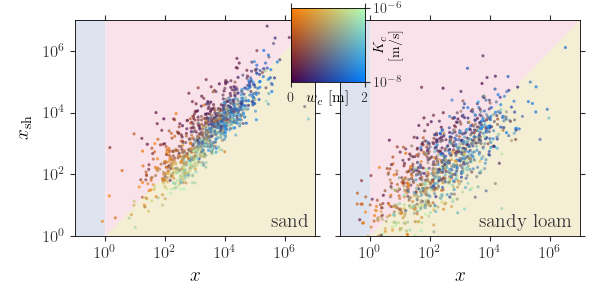

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
for ax in axs:
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(top=True, right=True)
    ax.set(xscale='log', yscale='log')
    ax.minorticks_off()
    ax.set_xlabel('$x$', labelpad=5)
    ax.set_xlim(xmin=1e-1, xmax=1e7)
    ax.set_ylim(ymin=1e0, ymax=1e7)
    ax.set_yticks([1e0, 1e2, 1e4, 1e6], labels=[])
    ax.set_xticks([1e0, 1e2, 1e4, 1e6])



# build 2d colormap
norm1 = colors.LogNorm(vmin=1e-8, vmax=1e-6)
norm2 = colors.Normalize(vmin=0, vmax=2)
rgb, stamp = colorstamps.apply_stamp(norm1(cl_cond), norm2(cl_th), 'teuling1f')



# scatter plot for sandy aquifer
_, _, _, x, x_sh = dless.get_dless_parameters(cl_cond, cl_th, sand['K'],
                                              sand['hg'], sand['n'], 'vGM')
axs[0].scatter(x, x_sh, c=rgb, marker='o', s=5, ec='None', alpha=0.7, zorder=1)
print(f'[SAND] unclogged fraction: {(x_sh <= 1).mean():.2f}')



# scatter plot for loamy aquifer
_, _, _, x, x_sh = dless.get_dless_parameters(cl_cond, cl_th, sand_loam['K'],
                                              sand_loam['hg'], sand_loam['n'],
                                              'vGM')
axs[1].scatter(x, x_sh, c=rgb, marker='o', s=5, ec='None', alpha=0.7, zorder=1)
print(f'[SAND LOAM] unclogged fraction: {(x_sh <= 1).mean():.2f}')



# background with the regimes
for ax in axs:
    ax.fill_betweenx([1e0, 1e7], [1e-2, 1e-2], x2=[1e0, 1e0], color=c_negl,
                     ec='None', zorder=0, alpha=0.2)
    ax.fill_between([1e0, 1e10], [1e0, 1e10], y2=[1e10, 1e10], color=c_soft,
                    ec='None', zorder=0, alpha=0.2)
    ax.fill_between([1e0, 1e10], [1e0, 1e0], y2=[1e0, 1e10], color=c_hard,
                    ec='None', zorder=0, alpha=0.2)



# layout
axs[0].set_ylabel('$x_\\mathrm{sh}$', labelpad=8)
axs[0].set_yticklabels(['$10^0$', '$10^2$', '$10^4$', '$10^6$'])

col_ax = stamp.overlay_ax(axs[0], lower_left_corner=[0.8, 1.02], width=0.35)
col_ax.spines["top"].set_visible(True)
col_ax.spines["right"].set_visible(True)
col_ax.tick_params(top=True, right=True)
col_ax.set_xlabel('$w_c$ [m]', labelpad=-10, fontsize=11)
col_ax.set_xticks([0, 1], labels=[0, 2], fontsize=10)
col_ax.set_ylabel('$K_c$\n[m/s]', labelpad=-20, fontsize=10,
                  multialignment='center')
col_ax.set_yticks([0, 1], labels=['$10^{-8}$', '$10^{-6}$'], fontsize=10)
col_ax.yaxis.set_label_position("right")
col_ax.yaxis.tick_right()

axs[0].text(6e6, 2e0, 'sand', horizontalalignment='right', fontsize=14)
axs[1].text(6e6, 2e0, 'sandy loam', horizontalalignment='right', fontsize=14)

plt.tight_layout()
#plt.savefig(output_path / 'riverbed_profiles.pdf')

plot together for manuscript figure

Bruen2004
Brunner2009a
Brunner2009b
Fox2003
Irvine2012
Newcomer2016
Osman2002
Riviere2014
Shanafield2012
Xian2017
Wang2011
BattleAguilar2012
Kalbus2009
Battin1998
Brookfield2009
Crosbie2014
Fleckenstein2006


/home/jonas/shared/Work/SSeep2026/stream-seepage/experiments/map.py:278: RuntimeWarning: invalid value encountered in scalar power
  if (ne_new**2-ne_old**2)**.5 + (d50_new**2-d50_old**2)**.5 < 1e-4:


Lamontagne2012
Reid1990
Su2007
Younger1993
Younger1993
[SAND] unclogged fraction: 0.00
[LOAM] unclogged fraction: 0.02


/tmp/ipykernel_13293/1291764065.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


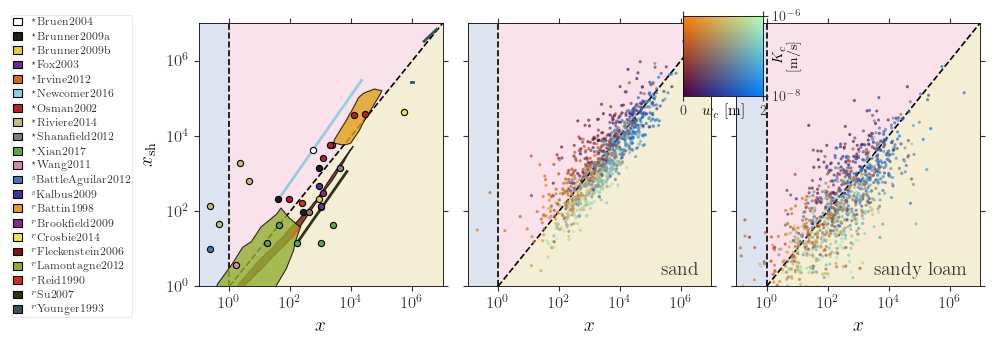

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
for ax in axs:
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.tick_params(top=True, right=True)
    ax.set(xscale='linear', yscale='linear')
    ax.minorticks_off()
    ax.set_xlim(xmin=-1, xmax=7)
    ax.set_ylim(ymin=0, ymax=7)
    ax.set_yticks([0, 2, 4, 6], labels=[])
    ax.set_xticks([0, 2, 4, 6])
    ax.set_xlabel('$x$', labelpad=5)
    ax.set_xticklabels(['$10^0$', '$10^2$', '$10^4$', '$10^6$'])
axs[0].set_ylabel('$x_\\mathrm{sh}$', labelpad=8)
axs[0].set_yticklabels(['$10^0$', '$10^2$', '$10^4$', '$10^6$'])



# plot complilation
labels = []
for x in sb:
    color = colorPalette[x['id'] - 1]
    plot_streambed(x, axs[0], labels, color)



# generate riverbed profiles
N = 1000
sand = rose.sample_from_class('SAND', N)
loam = rose.sample_from_class('SAND_LOAM', N)
cl_cond = 10**np.random.uniform(low=-8, high=-6, size=N)
cl_th = np.random.uniform(low=0, high=2, size=N)



# build 2d colormap
norm1 = colors.LogNorm(vmin=1e-8, vmax=1e-6)
norm2 = colors.Normalize(vmin=0, vmax=2)
rgb, stamp = colorstamps.apply_stamp(norm1(cl_cond), norm2(cl_th), 'teuling1f')



# scatter plot for sandy aquifer
_, _, _, x, x_sh = dless.get_dless_parameters(cl_cond, cl_th, sand['K'],
                                                sand['hg'], sand['n'], 'vGM')
axs[1].scatter(np.log10(x), np.log10(x_sh), c=rgb, marker='o', s=5, ec='None',
               alpha=0.7, zorder=1)
print(f'[SAND] unclogged fraction: {(x_sh <= 1).mean():.2f}')



# scatter plot for loamy aquifer
_, _, _, x, x_sh = dless.get_dless_parameters(cl_cond, cl_th, loam['K'],
                                                loam['hg'], loam['n'], 'vGM')
axs[2].scatter(np.log10(x), np.log10(x_sh), c=rgb, marker='o', s=5, ec='None',
               alpha=0.7, zorder=1)
print(f'[LOAM] unclogged fraction: {(x_sh <= 1).mean():.2f}')



# background with the regimes
for ax in axs:
    ax.fill_betweenx([0, 7], [-2, -2], x2=[0, 0], color=c_negl,
                    ec='None', zorder=0, alpha=0.2)
    ax.fill_between([0, 10], [0, 10], y2=[10, 10], color=c_soft,
                    ec='None', zorder=0, alpha=0.2)
    ax.fill_between([0, 10], [0, 0], y2=[0, 10], color=c_hard,
                    ec='None', zorder=0, alpha=0.2)
    ax.plot([0, 0], [0, 10], ls='--', c='k', zorder=0)
    ax.plot([0, 10], [0, 10], ls='--', c='k', zorder=0)



# layout
col_ax = stamp.overlay_ax(axs[1], lower_left_corner=[0.8, 1.25], width=0.35)
col_ax.spines["top"].set_visible(True)
col_ax.spines["right"].set_visible(True)
col_ax.tick_params(top=True, right=True)
col_ax.set_xlabel('$w_c$ [m]', labelpad=-10, fontsize=11)
col_ax.set_xticks([0, 1], labels=[0, 2], fontsize=10)
col_ax.set_ylabel('$K_c$\n[m/s]', labelpad=-20, fontsize=10, multialignment='center')
col_ax.set_yticks([0, 1], labels=['$10^{-8}$', '$10^{-6}$'], fontsize=10)
col_ax.yaxis.set_label_position("right")
col_ax.yaxis.tick_right()

axs[1].text(6.6, 0.3, 'sand', horizontalalignment='right', fontsize=14)
axs[2].text(6.6, 0.3, 'sandy loam', horizontalalignment='right', fontsize=14)

axs[0].legend(handles=labels, loc='upper right', bbox_to_anchor=(-0.25, 1.05),
              fontsize=8, handlelength=0.8, ncols=1, columnspacing=0.8)

plt.tight_layout()
#plt.savefig(output_path / 'streambeds.pdf')